<a href="https://colab.research.google.com/github/eniompw/microgpt/blob/dev/microgpt_fast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MicroGPT — PyTorch (Colab T4 GPU)

The most atomic way to train and run inference for a GPT in pure PyTorch.
Based on [@karpathy](https://github.com/karpathy)'s microgpt.

> **Runtime:** Go to **Runtime → Change runtime type → T4 GPU** before running.

## 1. GPU Setup and Library Imports

In [8]:
import os
import random
import json
import torch
import torch.nn.functional as F

# Reproducibility
random.seed(42)
torch.manual_seed(42)

# Device setup — will use T4 GPU on Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Dataset Download and Preparation

In [9]:
import pandas as pd

if not os.path.exists('input.txt'):
    print("Downloading TinyStories dataset from HuggingFace...")
    df = pd.read_parquet("hf://datasets/karpathy/tinystories-gpt4-clean/tinystories_gpt4_clean.parquet")
    stories = df['text'].iloc[20000:25000].tolist()  # 5000 stories
    with open('input.txt', 'w') as f:
        for story in stories:
            f.write(json.dumps(story) + '\n')
    print(f"Saved {len(stories)} stories to input.txt")
else:
    print("input.txt already exists, skipping download.")

docs = [json.loads(line) for line in open('input.txt') if line.strip()]
random.shuffle(docs)
print(f"num docs: {len(docs)}")
print(f"sample doc: {docs[0][:120]}...")

input.txt already exists, skipping download.
num docs: 5000
sample doc: Ben and Lily were playing in the farm with their new friend, Mira the mule. Mira was very strong and gentle, and she lik...


## 3. Tokenizer Setup

In [10]:
# Character-level vocabulary — all 74 chars present in the dataset
uchars = sorted('\n !"$\',-.' + '0123456789:;?' + 'ABCDEFGHIJKLMNOPQRSTUVWXYZ' + 'abcdefghijklmnopqrstuvwxyz')
BOS = len(uchars)          # special Beginning-of-Sequence token id
vocab_size = len(uchars) + 1
print(f"vocab size: {vocab_size}")
print(f"BOS token id: {BOS}")

# Encode / decode helpers
stoi = {ch: i for i, ch in enumerate(uchars)}
encode = lambda s: [stoi[ch] for ch in s]
decode = lambda ids: ''.join(uchars[i] for i in ids)

# Sanity check
sample_text = "Once upon a time"
encoded = encode(sample_text)
decoded = decode(encoded)
print(f"encode('{sample_text}') → {encoded}")
print(f"decode(...)           → '{decoded}'")

vocab size: 75
BOS token id: 74
encode('Once upon a time') → [36, 61, 50, 52, 1, 68, 63, 62, 61, 1, 48, 1, 67, 56, 60, 52]
decode(...)           → 'Once upon a time'


## 4. Model Hyperparameters and Parameter Initialization

In [11]:
import math

# ── Hyperparameters ────────────────────────────────────────────────────────
n_layer    = 6       # transformer depth
n_embd     = 256     # embedding dim
block_size = 256     # context window
n_head     = 8       # attention heads
head_dim   = n_embd // n_head
batch_size = 64      # sequences per gradient step

# ── Weight init ───────────────────────────────────────────────────────────
matrix = lambda nout, nin: torch.randn(nout, nin, device=device) * 0.02

state_dict = {
    'wte': matrix(vocab_size, n_embd),   # token embeddings (weight-tied to lm_head)
}
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)

params = list(state_dict.values())
for p in params:
    p.requires_grad_(True)

total_params = sum(p.numel() for p in params)
print(f"num params: {total_params:,}")
print(f"tokens per iter: {batch_size * block_size:,}")

num params: 4,737,792
tokens per iter: 16,384


## 5. Model Architecture Definition

Llama-style transformer: RMSNorm, RoPE, flash attention, weight tying.
The core forward pass stays explicit for teaching; only boilerplate is factored out elsewhere.

In [12]:
def rmsnorm(x):
    """RMSNorm along last dim — works for any shape."""
    return x * (x.pow(2).mean(-1, keepdim=True) + 1e-5).rsqrt()

# ── RoPE (Rotary Position Embeddings) ────────────────────────────────────────
freqs = 1.0 / (10000.0 ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim))
freqs = torch.outer(torch.arange(block_size, device=device).float(), freqs)
rope_cos, rope_sin = freqs.cos(), freqs.sin()   # (block_size, head_dim//2)

def apply_rope(x, cos, sin):
    """x: (B,T,H,D) or (H,D). cos/sin: (T,D//2) or (D//2,)"""
    d = x.dtype
    x = x.float().unflatten(-1, (-1, 2))
    x_r, x_i = x[..., 0], x[..., 1]
    if x.dim() == 5:  # batched
        cos = cos.view(1, -1, 1, cos.shape[-1])
        sin = sin.view(1, -1, 1, sin.shape[-1])
    return torch.stack([x_r*cos - x_i*sin, x_r*sin + x_i*cos], -1).flatten(-2).to(d)

# ── Batched forward (for training) ───────────────────────────────────────────
def gpt_train(tokens):
    """tokens: (B, T) long -> logits: (B, T, vocab_size)"""
    bsz, seqlen = tokens.shape
    x = rmsnorm(F.embedding(tokens, state_dict['wte']))
    cos, sin = rope_cos[:seqlen], rope_sin[:seqlen]
    for li in range(n_layer):
        r = x
        x = rmsnorm(x)
        q = F.linear(x, state_dict[f'layer{li}.attn_wq']).view(bsz, seqlen, n_head, head_dim)
        k = F.linear(x, state_dict[f'layer{li}.attn_wk']).view(bsz, seqlen, n_head, head_dim)
        v = F.linear(x, state_dict[f'layer{li}.attn_wv']).view(bsz, seqlen, n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        x = F.scaled_dot_product_attention(
            q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2), is_causal=True
        ).transpose(1, 2).contiguous().view(bsz, seqlen, -1)
        x = F.linear(x, state_dict[f'layer{li}.attn_wo']) + r
        r = x
        x = rmsnorm(x)
        x = F.silu(F.linear(x, state_dict[f'layer{li}.mlp_fc1']))
        x = F.linear(x, state_dict[f'layer{li}.mlp_fc2']) + r
    return F.linear(rmsnorm(x), state_dict['wte'])   # weight-tied lm_head

gpt_train = torch.compile(gpt_train)  # fuse GPU kernels for ~2x speedup
print(f"torch.compile cache: {os.getenv('TORCHINDUCTOR_CACHE_DIR', '~/.cache/torch/inductor')}")

# ── Single-token forward (for inference with KV cache) ───────────────────────
def gpt(token_id, pos_id, keys, values):
    x = rmsnorm(state_dict['wte'][token_id])
    cos, sin = rope_cos[pos_id], rope_sin[pos_id]
    for li in range(n_layer):
        r = x
        x = rmsnorm(x)
        q = F.linear(x, state_dict[f'layer{li}.attn_wq']).view(n_head, head_dim)
        k = F.linear(x, state_dict[f'layer{li}.attn_wk']).view(n_head, head_dim)
        v = F.linear(x, state_dict[f'layer{li}.attn_wv']).view(n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        keys[li].append(k)
        values[li].append(v)
        x_attn = []
        for h in range(n_head):
            k_h = torch.stack([ki[h] for ki in keys[li]])
            v_h = torch.stack([vi[h] for vi in values[li]])
            x_attn.append(F.softmax(k_h @ q[h] / head_dim**0.5, dim=0) @ v_h)
        x = F.linear(torch.cat(x_attn), state_dict[f'layer{li}.attn_wo']) + r
        r = x
        x = rmsnorm(x)
        x = F.silu(F.linear(x, state_dict[f'layer{li}.mlp_fc1']))
        x = F.linear(x, state_dict[f'layer{li}.mlp_fc2']) + r
    return F.linear(rmsnorm(x), state_dict['wte'])

print("Model functions defined.")

torch.compile cache: /tmp/torchinductor_root
Model functions defined.


## 6. Training Loop

Total tokens: 4,051,708
step    0/3500 | loss 5.2302 | lr 0.00e+00 | 2.1s
step  100/3500 | loss 2.2199 | lr 5.00e-04 | 13.5s
step  200/3500 | loss 1.5357 | lr 1.00e-03 | 19.5s
step  300/3500 | loss 1.2806 | lr 9.98e-04 | 25.6s
step  400/3500 | loss 1.1383 | lr 9.92e-04 | 31.7s
step  500/3500 | loss 1.0509 | lr 9.82e-04 | 38.0s
step  600/3500 | loss 1.0026 | lr 9.68e-04 | 44.6s
step  700/3500 | loss 0.9651 | lr 9.50e-04 | 51.2s
step  800/3500 | loss 0.9232 | lr 9.29e-04 | 57.5s
step  900/3500 | loss 0.9374 | lr 9.04e-04 | 63.6s
step 1000/3500 | loss 0.8719 | lr 8.76e-04 | 69.6s
step 1100/3500 | loss 0.8461 | lr 8.45e-04 | 75.7s
step 1200/3500 | loss 0.8264 | lr 8.11e-04 | 81.7s
step 1300/3500 | loss 0.8253 | lr 7.75e-04 | 87.6s
step 1400/3500 | loss 0.8364 | lr 7.37e-04 | 93.6s
step 1500/3500 | loss 0.7864 | lr 6.97e-04 | 99.7s
step 1600/3500 | loss 0.7693 | lr 6.56e-04 | 105.8s
step 1700/3500 | loss 0.7504 | lr 6.14e-04 | 111.9s
step 1800/3500 | loss 0.7708 | lr 5.71e-04 | 118.0s
step 

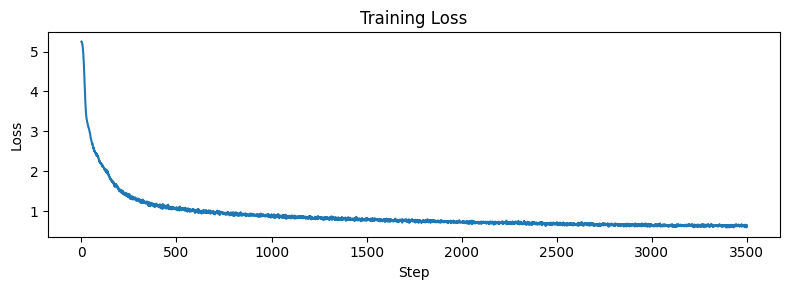

In [13]:
import time
import matplotlib.pyplot as plt

# ── Prepare token stream ─────────────────────────────────────────────────────
all_tokens = [BOS]
for doc in docs:
    all_tokens.extend(encode(doc) + [BOS])
all_tokens = torch.tensor(all_tokens, dtype=torch.long, device=device)
print(f"Total tokens: {len(all_tokens):,}")

def get_batch():
    starts = torch.randint(0, len(all_tokens) - block_size - 1, (batch_size,))
    xb = torch.stack([all_tokens[i : i + block_size] for i in starts])
    yb = torch.stack([all_tokens[i + 1 : i + block_size + 1] for i in starts])
    return xb, yb

# ── Optimizer: AdamW ─────────────────────────────────────────────────────────
num_steps     = 3500
warmup_steps  = 200
learning_rate = 1e-3
min_lr        = 1e-4   # 10% of peak — prevents wasted steps at tail

def get_lr(step):
    if step < warmup_steps:
        return learning_rate * step / warmup_steps
    progress = (step - warmup_steps) / (num_steps - warmup_steps)
    return min_lr + (learning_rate - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

optimizer = torch.optim.AdamW(params, lr=learning_rate, betas=(0.9, 0.95), eps=1e-10)

# Mixed precision (float16 on T4)
scaler = torch.amp.GradScaler('cuda')

# ── Training loop ────────────────────────────────────────────────────────────
loss_history = []
t0 = time.time()

for step in range(num_steps + 1):
    lr_t = get_lr(step)
    for g in optimizer.param_groups:
        g['lr'] = lr_t

    if step % 100 == 0:
        xb, yb = get_batch()
        with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
            el = F.cross_entropy(gpt_train(xb).view(-1, vocab_size), yb.view(-1)).item()
        print(f"step {step:4d}/{num_steps} | loss {el:.4f} | lr {lr_t:.2e} | {time.time()-t0:.1f}s")

    if step >= num_steps:
        break

    optimizer.zero_grad(set_to_none=True)
    xb, yb = get_batch()
    with torch.amp.autocast('cuda', dtype=torch.float16):
        loss = F.cross_entropy(gpt_train(xb).view(-1, vocab_size), yb.view(-1))
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(params, 1.0)
    scaler.step(optimizer)
    scaler.update()
    loss_history.append(loss.item())

print(f"\nDone in {time.time()-t0:.1f}s")
plt.figure(figsize=(8, 3))
plt.plot(loss_history)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Training Loss')
plt.tight_layout(); plt.show()

## 7. Inference and Text Generation

In [14]:
temperature = 0.7   # (0, 1] — lower = more focused, higher = more random
num_samples = 5
max_new_tokens = 200  # generate up to this many tokens per sample

def generate_sample(max_new_tokens=200, temperature=0.7):
    keys = [[] for _ in range(n_layer)]
    values = [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    with torch.no_grad():
        for pos_id in range(max_new_tokens):
            logits = gpt(token_id, min(pos_id, block_size - 1), keys, values)
            probs = F.softmax(logits[:vocab_size] / temperature, dim=-1)
            token_id = torch.multinomial(probs, 1).item()
            if token_id == BOS:
                break
            sample.append(uchars[token_id])
    return ''.join(sample)

print("--- inference (hallucinated stories) ---\n")
t0 = time.time()
for sample_idx in range(num_samples):
    print(f"sample {sample_idx+1}:\n{generate_sample(max_new_tokens, temperature)}\n")
print(f"Done in {time.time()-t0:.1f}s")

--- inference (hallucinated stories) ---

sample 1:
Once upon a time, there was a little boy named Tim. Tim had a big rock. He liked to play with his toys, but his friend, a little girl named Lily. She had a big house and a small dog. Tim loved to play

sample 2:
Once upon a time, there was a little girl named Lucy. She had a big red home in the backyard. Lucy was very old and had red and she was happy to see the wrapes on the ground.
One day, Lucy's mom said,

sample 3:
Once upon a time, in a small town, there lived a small dog named Spot. Spot loved to play with his friend, a little girl named Mia. She was a big, brown dog who lived in a big garden.
One day, Mimi an

sample 4:
Once upon a time, in a complete living around the village had a fun time at the park. The person was very excited and a small mehich just because it could not see the toys instead. The people in the t

sample 5:
Once upon a time, there was a little girl named Emma. She loved to play with her toys and see what w